# Assignment 3: Recurrent Neural Network (RNN) {-}

This assignment aims at familiarizing you with training and testing the RNN neural network for an image classification task. You will go through the process of loading data, preprocessing images, building the RNN model, and evaluating its performance.

The assignment rqeuirements include:
- **3.1 (1 point)** Load the dataset.
- **3.2 (1 point)** Analyze and process the dataset.
- **3.3 (2 points)** Construct an RNN model using GRU (Gated Recurrent Unit) instead of LSTM, as demonstrated in the demo code (https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU). Train and evaluate the model’s performance on the test set.
- **3.4 (2 points)** Construct an RNN model using Bidirectional LSTM (BiLSTM, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional). Train and evaluate the model’s performance on the test set.
- **3.5 (2 points)** Construct an RNN model using Bidirectional GRU (BiGRU, https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional). Train and evaluate the model’s performance on the test set.
- **3.6 (2 points)** Compare the accuracy and runtime efficiency among LSTM, GRU, BiLSTM, and BiGRU models. Provide comments and observations on the performance of each model variant.

The dataset you will be working on is imdb_reviews. This dataset is a large movie review dataset. This dataset is for binary sentiment classification containing a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. All the reviews have either a positive or negative sentiment. Reference: http://ai.stanford.edu/~amaas/data/sentiment/

Each data sample contains:
- label (tf.int64)
- text (tf.string)

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment3-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named DL4AI-\<StudentID>-Assignment3 (e.g., DL4AI-2012345-Assigment3) and then compressed with the same name.

### Evaluation {-}
Assignment evaluation will be conducted on how you accomplish the assignment requirements. The model accuracy on the test set is one of the most important evaluation criteria. Therefore try to push it as high as possible. In addition, your code should conform to a Python coding convention such as PEP-8.

### Deadline {-}
Please visit Canvas for details.

# Process the dataset

In [1]:
# Note: to enable GPU training in Colab, go to Runtime > Change runtime type > Hardware acceleration > Choose GPU from the drop-down list.

# Download tensorflow datasets
!pip install tensorflow_datasets
# Import libraries
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# Load the IMDB movie review dataset, return text (movie review) and label (positive/negative)
train_dataset, val_dataset, test_dataset = tfds.load(name="imdb_reviews", split=('train[:80%]', 'train[80%:]', 'test'), as_supervised=True)

print("Training set: ", len(train_dataset), "samples")
print("Validation set: ", len(val_dataset), "samples")
print("Test set: ", len(test_dataset), "samples")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6UCP2N_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...:   0%|          | 0/25000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6UCP2N_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...:   0%|          | 0/50000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.6UCP2N_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Training set:  20000 samples
Validation set:  5000 samples
Test set:  25000 samples


In [3]:
# Show same samples in the training set
for example, label in train_dataset.take(3):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0
text:  b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. 

In [4]:
# Convert training set
train_ds_numpy = tfds.as_numpy(train_dataset)
train_numpy = np.vstack(list(train_ds_numpy))
X_train = tf.convert_to_tensor(list(map(lambda x: x[0], train_numpy)), dtype=tf.string) # Extract review (index 0) from numpy vector
y_train = np.array(list(map(lambda x: x[1], train_numpy))).astype(np.int16)
print("X_train shape: " + str(X_train.shape))
print("y_train shape: " + str(y_train.shape))

X_train shape: (20000,)
y_train shape: (20000,)


In [5]:
X_train[0]

<tf.Tensor: shape=(), dtype=string, numpy=b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.">

In [6]:
# Convert validation set
val_ds_numpy = tfds.as_numpy(val_dataset)
val_numpy = np.vstack(list(val_ds_numpy))
X_val = tf.convert_to_tensor(list(map(lambda x: x[0], val_numpy)))
y_val = np.array(list(map(lambda x: x[1], val_numpy))).astype(np.int16)
print("X_val shape: " + str(X_val.shape))
print("y_val shape: " + str(y_val.shape))

X_val shape: (5000,)
y_val shape: (5000,)


In [7]:
# Convert test set
test_ds_numpy = tfds.as_numpy(test_dataset)
test_numpy = np.vstack(list(test_ds_numpy))
X_test = tf.convert_to_tensor(list(map(lambda x: x[0], test_numpy)))
y_test = np.array(list(map(lambda x: x[1], test_numpy))).astype(np.int16)
print("X_test shape: " + str(X_test.shape))
print("y_test shape: " + str(y_test.shape))

X_test shape: (25000,)
y_test shape: (25000,)


# Encode the text

In [8]:
VOCAB_SIZE = 1000
# Initialize the TextVectorization layer for raw text encoding
text_encoder = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE) # Maximum size of the vocabulary
# Feed training text to adapt() method to calculate the layer's vocabulary
text_encoder.adapt(X_train)

In [9]:
vocab = np.array(text_encoder.get_vocabulary())
print("Vocabulary size:", vocab.shape)
vocab[:20]

Vocabulary size: (1000,)


array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U14')

In [10]:
# Create the model that uses the text vectorization layer
model_encoder = tf.keras.models.Sequential()
model_encoder.add(tf.keras.Input(shape=(1,), dtype=tf.string))
model_encoder.add(text_encoder)

In [11]:
test_data = [["I want to drink"], ["I do not want to eat but I want to sleep"]]
test_data = tf.convert_to_tensor(test_data, dtype=tf.string)
predictions = model_encoder.predict(test_data)
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
[[ 10 179   6   1   0   0   0   0   0   0   0]
 [ 10  79  22 179   6   1  19  10 179   6   1]]


# RNN model using GRU

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),  # Input layer for text
    text_encoder,  # Text encoder layer
    tf.keras.layers.Embedding(input_dim=len(text_encoder.get_vocabulary()), output_dim=64, mask_zero=True),
    tf.keras.layers.GRU(units=64),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Summarize the model
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ (None, None)                │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, None, 64)            │          64,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,185 (364.00 KB)

 Trainable params: 93,185 (364.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-3), metrics=['accuracy'])
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size = 256, validation_data=(X_val, y_val))

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.5544 - loss: 0.6898 - val_accuracy: 0.6528 - val_loss: 0.6248
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.6816 - loss: 0.6019 - val_accuracy: 0.7150 - val_loss: 0.5530
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.7561 - loss: 0.5008 - val_accuracy: 0.8260 - val_loss: 0.3980
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.8221 - loss: 0.3989 - val_accuracy: 0.8228 - val_loss: 0.3835
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8566 - loss: 0.3387 - val_accuracy: 0.8494 - val_loss: 0.3484
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8612 - loss: 0.3294 - val_accuracy: 0.8550 - val_loss: 0.3411
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.8640 - loss: 0.3260 - val_accuracy: 0.8558 - val_loss: 0.3434
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.8734 - loss: 0.3044 - val_accuracy: 0.8680 -

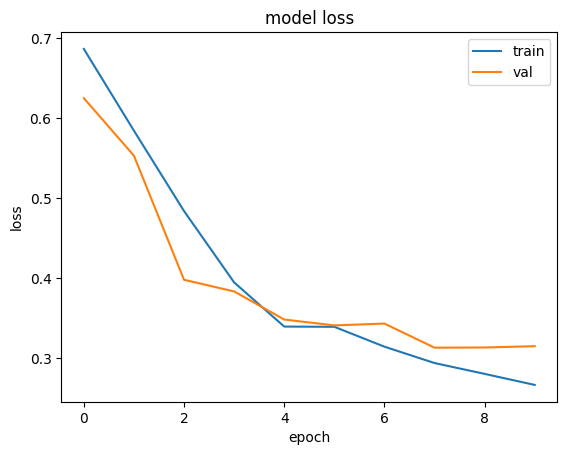

In [ ]:
# Visualize the training and validation loss over epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

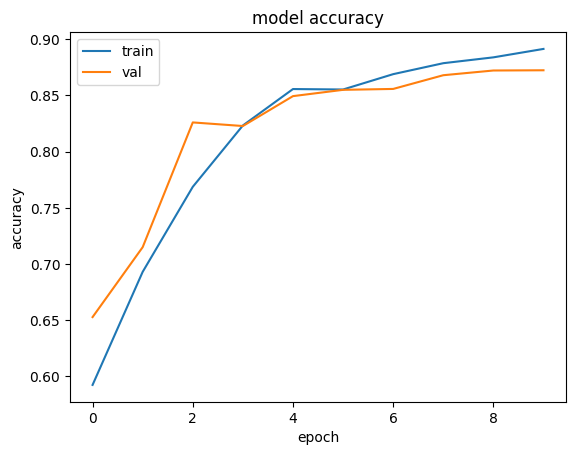

In [ ]:
# Visualize the training and validation accuracy over epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8720 - loss: 0.3092
Test Loss: 0.3056195378303528
Test Accuracy: 0.8734800219535828


# RNN model using Bidirectional LSTM

In [61]:
model_1 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),  # Input layer for text
    text_encoder,  # Text encoder layer
    tf.keras.layers.Embedding(input_dim=len(text_encoder.get_vocabulary()), output_dim=64, mask_zero=True),

    # Bidirectional LSTM layers
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64, return_sequences=True)),  # First LSTM with return_sequences=True
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(units=64, return_sequences=False)),  # Second LSTM without return_sequences

    # Dense layers
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])
model_1.summary()


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ (None, None)                │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_19 (Embedding)             │ (None, None, 64)            │          64,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_32 (Bidirectional)     │ (None, None, 128)           │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_33 (Bidirectional)     │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 237,185 (926.50 KB)

 Trainable params: 237,185 (926.50 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Compile the model
model_1.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-2), metrics=['accuracy'])

In [64]:
# Train the model
history_1 = model_1.fit(X_train, y_train, epochs=10, batch_size = 512, validation_data=(X_val, y_val))

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 321ms/step - accuracy: 0.5250 - loss: 0.7015 - val_accuracy: 0.6696 - val_loss: 0.6134
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.7247 - loss: 0.5425 - val_accuracy: 0.7766 - val_loss: 0.4955
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.8153 - loss: 0.4238 - val_accuracy: 0.8422 - val_loss: 0.3894
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 311ms/step - accuracy: 0.8439 - loss: 0.3646 - val_accuracy: 0.8402 - val_loss: 0.3628
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.8588 - loss: 0.3323 - val_accuracy: 0.8488 - val_loss: 0.3650
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 309ms/step - accuracy: 0.8605 - loss: 0.3284 - val_accuracy: 0.8494 - val_loss: 0.3446
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 306ms/step - accuracy: 0.8756 - loss: 0.2940 - val_accuracy: 0.8456 - val_loss: 0.3555
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step - accuracy: 0.8863 - loss: 0.2793 - val_accu

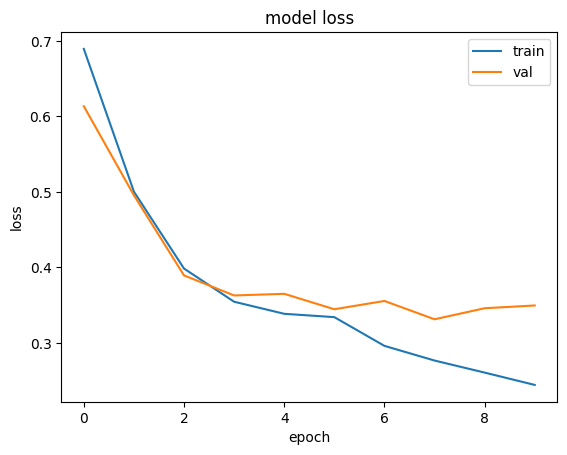

In [65]:
# Visualize the training and validation loss over epochs
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

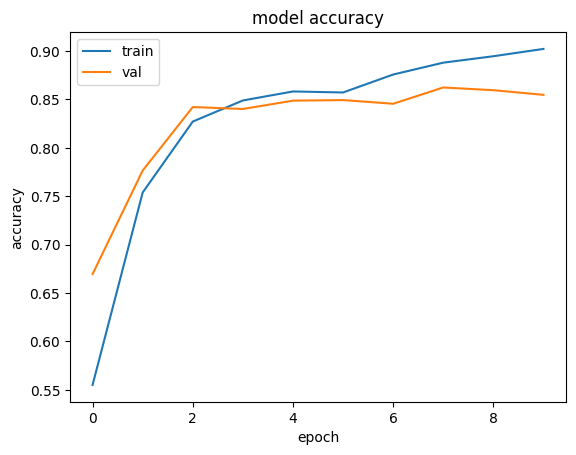

In [66]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [67]:
# Evaluate the model on the test set
test_loss, test_acc = model_1.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8581 - loss: 0.3460
Test Loss: 0.3428649306297302
Test Accuracy: 0.8590800166130066


# RNN model using Bidirectional GRU

In [76]:
model_2 = tf.keras.Sequential([
    tf.keras.Input(shape=(1,), dtype=tf.string),  # Input layer for text
    text_encoder,  # Text encoder layer
    tf.keras.layers.Embedding(input_dim=len(text_encoder.get_vocabulary()), output_dim=64, mask_zero=True),

    # Bidirectional GRU layers
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(units=64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(units=64, return_sequences=False)),

    # Dense layers
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])
model_2.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ text_vectorization                   │ (None, None)                │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_23 (Embedding)             │ (None, None, 64)            │          64,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_40 (Bidirectional)     │ (None, None, 128)           │          49,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_41 (Bidirectional)     │ (None, 128)                 │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 196,737 (768.50 KB)

 Trainable params: 196,737 (768.50 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# Compile the model
model_2.compile(loss='binary_crossentropy', # Binary classification loss
              optimizer=tf.keras.optimizers.Adam(1e-3), # Optimizer
              metrics=['accuracy']) # Evaluation metric


In [78]:
# Train the model
history_2 = model_2.fit(X_train, y_train,  epochs=10, batch_size=128, validation_data=(X_val, y_val))


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 169ms/step - accuracy: 0.5989 - loss: 0.6438 - val_accuracy: 0.7122 - val_loss: 0.7322
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - accuracy: 0.7678 - loss: 0.5039 - val_accuracy: 0.8162 - val_loss: 0.3956
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.8442 - loss: 0.3578 - val_accuracy: 0.8438 - val_loss: 0.3515
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 144ms/step - accuracy: 0.8616 - loss: 0.3243 - val_accuracy: 0.8616 - val_loss: 0.3252
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.8771 - loss: 0.2961 - val_accuracy: 0.8424 - val_loss: 0.3612
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 147ms/step - accuracy: 0.8758 - loss: 0.2933 - val_accuracy: 0.8638 - val_loss: 0.3274
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.8864 - loss: 0.2727 - val_accuracy: 0.8670 - val_loss: 0.3224
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 151ms/step - accuracy: 0.8943 - loss: 0

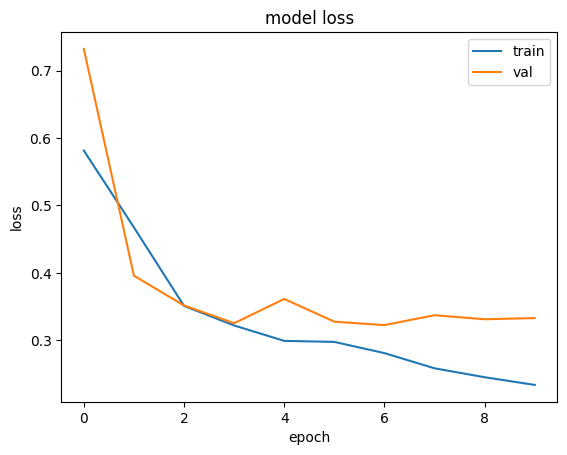

In [79]:
# Visualize the training and validation loss over epochs
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

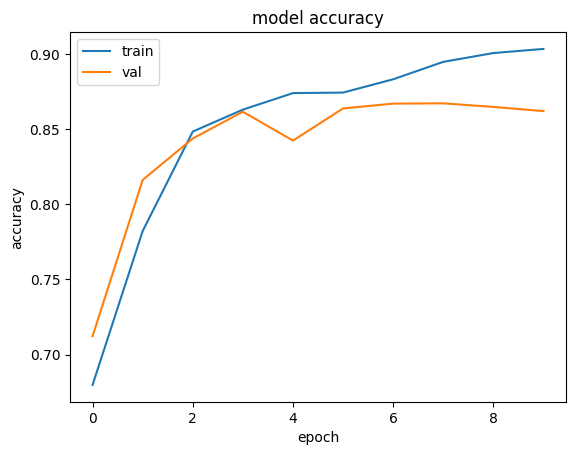

In [80]:
# Visualize the training and validation accuracy over epochs
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [81]:
# Evaluate the model on the test set
test_loss, test_acc = model_2.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8682 - loss: 0.3269
Test Loss: 0.322507381439209
Test Accuracy: 0.8703200221061707


Observation:
- Best Model for Accuracy and Efficiency: The GRU model performed the best overall in terms of balancing accuracy and runtime efficiency. It achieved the highest validation accuracy with the lowest training time
- BiLSTM and BiGRU: These models have higher computational costs due to their bidirectional nature. While BiGRU achieved a slightly higher training accuracy, the improvement in validation accuracy was not substantial enough to justify the longer training time compared to GRU